# Predicting Heart Disease
I will build a predictive Machine Learning model. Our target variable is binary (0 for healthy, 1 for disease), it is a **Classification** problem. I will use **Logistic Regression**.

Our ML pipeline will consist of:
1. **Data Preprocessing:** Encoding categorical variables and scaling continuous variables.
2. **Train/Test Split:** Dividing our data to evaluate the model on unseen data.
3. **Model Training:** Fitting the Logistic Regression algorithm.
4. **Evaluation:** Assessing performance using Accuracy and a Confusion Matrix.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# one-hot encoding
categorical_features = ['cp', 'restecg', 'slope', 'thal']
df_ml = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [6]:
df_ml.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,False,False,False,True,False,False,True,False,False,True
1,53,1,140,203,1,155,1,3.1,0,0,False,False,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,False,False,False,True,False,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,0,False,False,False,True,False,False,True,False,False,True
4,62,0,138,294,1,106,0,1.9,3,0,False,False,False,True,False,True,False,False,True,False


In [ ]:
# features X, target y
X = df_ml.drop('target', axis=1)
y = df_ml['target']

In [8]:
# train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**StandardScaler** is a preprocessing tool that standardizes features by removing the mean and scaling them to unit variance (mean = 0, standard deviation = 1).

It ensures that all continuous clinical variables contribute equally to the Machine Learning model, regardless of their original units or magnitude.

In [9]:
# standarization
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

In [10]:
# transforming
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

In [11]:
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (820, 19)
Testing data shape: (205, 19)


### Model Training and Evaluation (Confusion Matrix)
Accuracy alone can be misleading. In medical diagnostics, a **Confusion Matrix** is crucial because it shows us exactly *where* the model makes mistakes. We want to pay special attention to **False Negatives** (predicting a sick patient is healthy), as this is the most dangerous clinical error.

In [12]:
# initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [13]:
# predictions on the test set
y_pred = model.predict(X_test)

In [14]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%\n")

Logistic Regression Accuracy: 81.95%



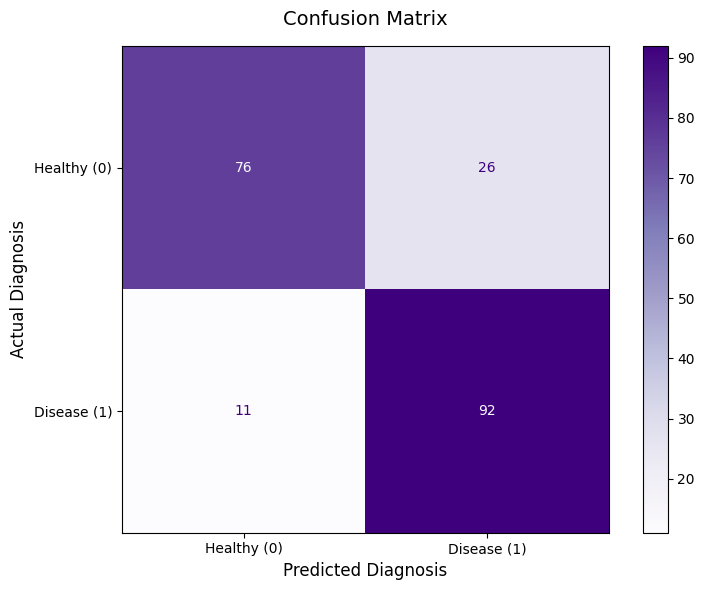

In [18]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Disease (1)'])

disp.plot(cmap='Purples', ax=ax, values_format='d')

plt.title('Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.grid(False) 
plt.tight_layout()
plt.show()

### Model Evaluation: Confusion Matrix Insights

While the model accuracy is **81.95%**, the Confusion Matrix provides a deeper understanding of how our Logistic Regression algorithm performs in a clinical context. 

Based on the test dataset of 205 patients, we can observe the following:

* **High Sensitivity (True Positives):** The model is highly effective at identifying sick patients. Out of 103 patients who actually have heart disease, the model successfully caught **92** of them. 
* **Low Critical Errors (False Negatives):** The most dangerous mistake in medical ML is sending a sick patient home. Our model only made this error **11** times.
* **Over-cautiousness (False Positives):** The model struggles slightly more with healthy patients. It incorrectly flagged **26** healthy individuals as having heart disease. In a real-world scenario, this would lead to unnecessary stress and follow-up testing for these patients, indicating the model is slightly "paranoid."
* **True Negatives:** The model correctly identified **76** healthy patients, sparing them from further unnecessary medical procedures.